<div class="markdown-google-sans">
  <h1>INTRODUÇÃO À CIÊNCIA DE DADOS E APRENDIZADO DE MÁQUINAS</h1>
</div>
*Material desenvolvido para a disciplina LOB1266 - Introdução à Ciência de Dados e Aprendizado de Máquinas da Escola de Engenharia de Lorena, Universidade de São Paulo.*

Prof. Dr. Fabiano Fernandes Bargos

Bolsistas: João Vitor Fernandes Gomes (Graduando em Engenharia Química)  
Projeto: `APRIMORAMENTO DE CONTEÚDOS DIDÁTICOS DA DISCIPLINA LOB1266 - INTRODUÇÃO À CIÊNCIA DE DADOS E APRENDIZADO DE MÁQUINAS`

# Setup

In [1]:
# Importando as bibliotecas extras usadas:
import pandas as pd
import numpy as np

In [34]:
# Importando uma DataFrame concatenada do INMET:
url = 'https://raw.githubusercontent.com/JCFDGG/LOB1266-PUB/refs/heads/main/ExemplosAula/2/seaborn.csv'
caminho = 'dados/seaborn.csv'
df = pd.read_csv(url, sep=';') # Lê a DataFrame, com ';' de separador
df = df.dropna() # Remove NaNs
df.head() # Mostra as 5 primeiras linhas da DataFrame

,Data Medicao,Precipitação Total,Pressão Atmosférica Média,Temperatura Máxima,Temperatura Média,Temperatura Mínima,Umidade Relativa do Ar,Velocidade do Vento,Cidade,Dia
0,2024-01-01,0.0,956.0,23.7,21.5,20.1,80.3,2.7,Afonso Claudio,1
1,2024-01-02,2.4,954.7,28.0,22.6,19.8,86.4,1.1,Afonso Claudio,2
2,2024-01-03,39.4,954.8,24.8,22.4,21.0,90.6,1.5,Afonso Claudio,3
3,2024-01-04,9.4,953.1,25.5,22.8,21.5,92.0,1.2,Afonso Claudio,4
4,2024-01-05,21.0,951.6,28.0,23.1,21.6,90.5,1.2,Afonso Claudio,5


# Matplotlib

**Pyplot** é um módulo da biblioteca **Matplotlib** usado para criar visualizações de dados em **Python**. Ele oferece funções simples para gerar gráficos como linhas, barras, dispersão e outros.

## Importar e usos simples
Para usar a biblioteca, primeiro é necessário importá-la:

In [4]:
import matplotlib.pyplot as plt

O uso mais simples, é através do método `plt.plot(x,y)` em que duas listas (ou itens iteráveis), de mesmo tamanho são desenhadas de forma de linha, em um gráfico; e então, usa-se `plt.show()` para mostrar a figura. Por exemplo:

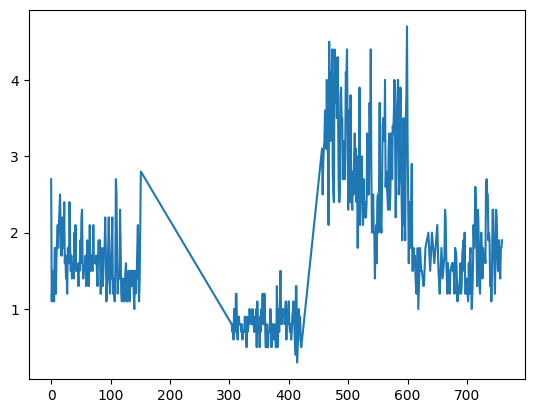

In [5]:
y = df['Velocidade do Vento'] # Usa a velocidade do vento como y
x = df.index # Usa o índice como x
plt.plot(x,y) # Faz um gráfico de linha com x, y.
plt.show() # Mostra o gráfico

Perceba que em casos que não há dados - como nas partes que foram removidas pelo `.dropna()`, o *matplotlib* desenha uma linha reta entre os dois pontos.

#### Histogramas
Histogramas de frequência também são facilmente feitos:


```
n = 5
plt.hist(lista, n)
plt.show()
```
Em que `n` é o número dede intervalos, separados igualmente:

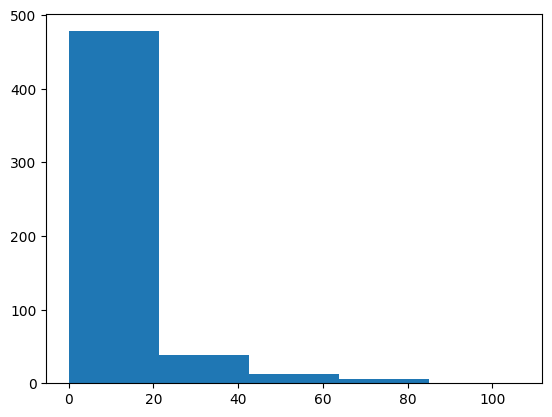

In [6]:
x = df['Precipitação Total'] # Usa a precipitação como X
plt.hist(x, 5) # Faz um gráfico de histograma dos dados, com 5 intervalos
plt.show() # Mostra o gráfico

#### Boxplots

**Matplotlib** também oferece muitos gráficos relacionados a estatística, como `plt.boxplot(lista_de_dados)`:

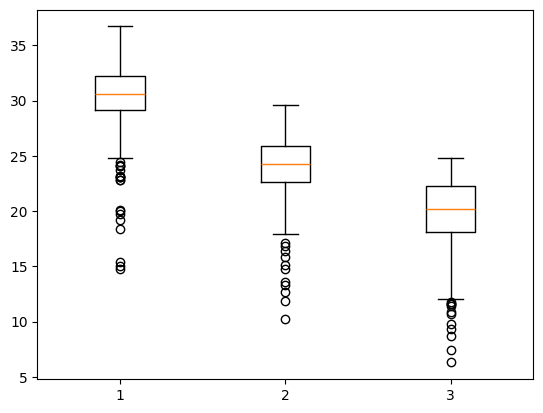

In [7]:
y1 = df['Temperatura Máxima']
y2 = df['Temperatura Média']
y3 = df['Temperatura Mínima']
plt.boxplot([y1, y2, y3]) # Faz um gráfico com a lista dos dados [x1, x2, x3]
plt.show() # Mostra o gráfico

### Outros gráficos
O **Matplotlib** possui inúmeros tipos de gráficos, catalogados em sua [documentação](https://matplotlib.org/stable/api/pyplot_summary.html#adding-data-to-the-plot),  onde também são explicados os diversos argumentos extras disponíveis para modificar o gráfico.

#### Atividade Prática

Acesse a página da [Matplotlib](https://matplotlib.org/stable/gallery/index.html) e estude mais um modelo de gráficos para visualização de dados.

<center>
  <a href="https://matplotlib.org/stable/gallery/index.html" target="_blank">
  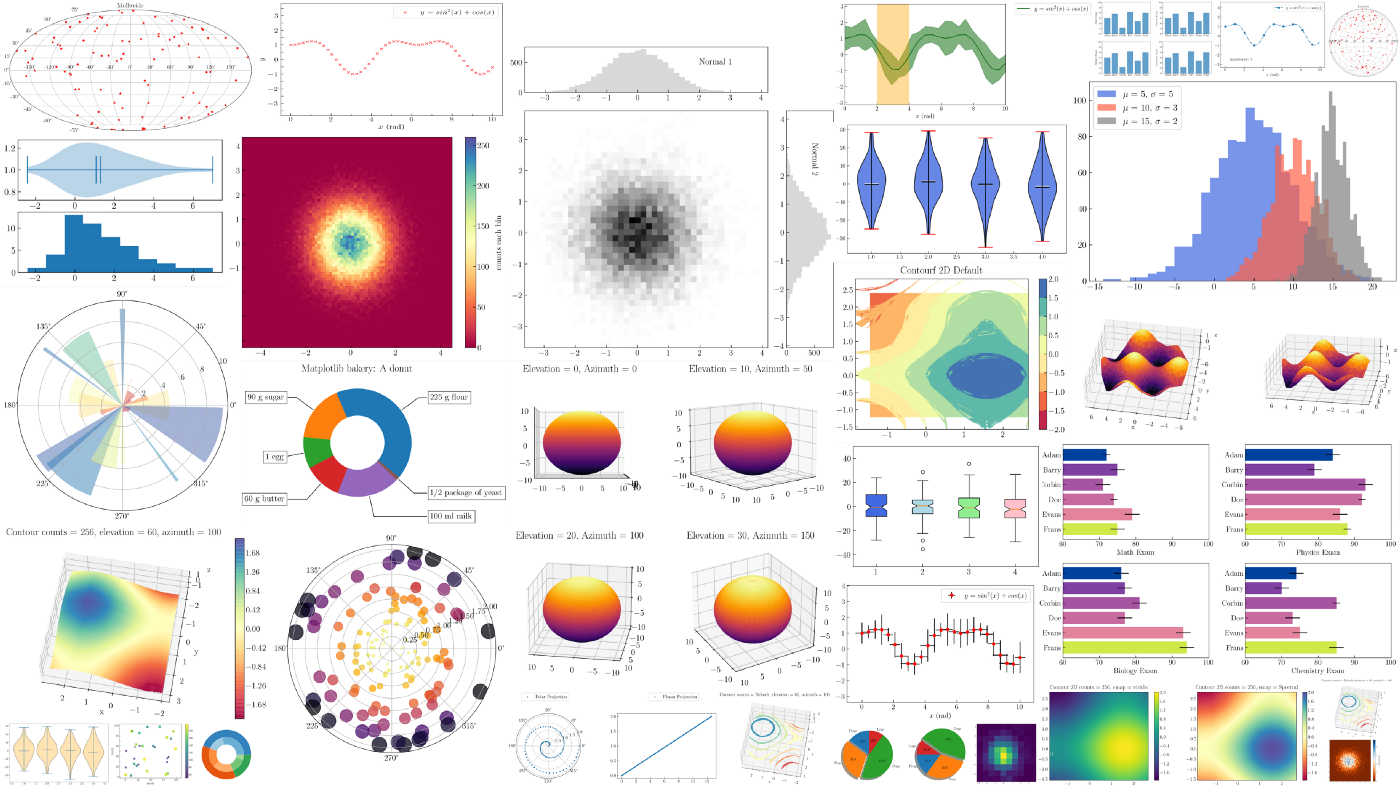
  </a>
</center>


## Modificações

O **matplotlib** também permite a modificação de linha, de cor, de tamanho, assim como outros.

É de interesse memorizar os principais, de cor, marker, estilo de linha e label:


```
plt.plot(x,y, color='Nome Da Cor', marker='Símbolo do ponto', linestyle='Estilo de linha', label='Rótulo')
```
Para elementos de linha, estão documentados em [Line2D](https://matplotlib.org/stable/api/_as_gen/matplotlib.lines.Line2D.html#matplotlib.lines.Line2D).


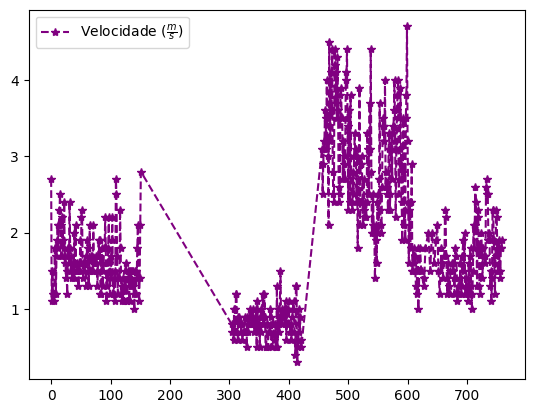

In [8]:
x = df.index # Usa o index como x
y = df['Velocidade do Vento'] # Usa Velocidade do Vento como y
plt.plot(x,y, # Gráficos de linha x e y
         color='Purple', # De cor roxa
         marker='*', # Com pontos de estrela
         linestyle='--', # Linha pontilhada
         label=r'Velocidade ($\frac{m}{s}$)') # Com legenda de velocidade

plt.legend() # Faz a legenda do gráfico

plt.show() # Mostra o gráfico

### Elementos de gráfico:
Elementos de gráficos, como título, e labels, também podem ser modficados. Porém, estas modificações exige introduzir uma variável específica para o gráfico, comumento chamada de `ax`:



```
fig, ax = plt.subplots()
ax.plot(x, y)
fig.show()
```

O uso de `plt.subplots()` retorna dois items, por isso se declaram duas variáveis em apenas uma linha: `fig, ax`

Todas as funções de graficar são aplicadas em `ax`, e funções para a figura em completa, como mudar de tamanho, são aplicadas em `figure`:

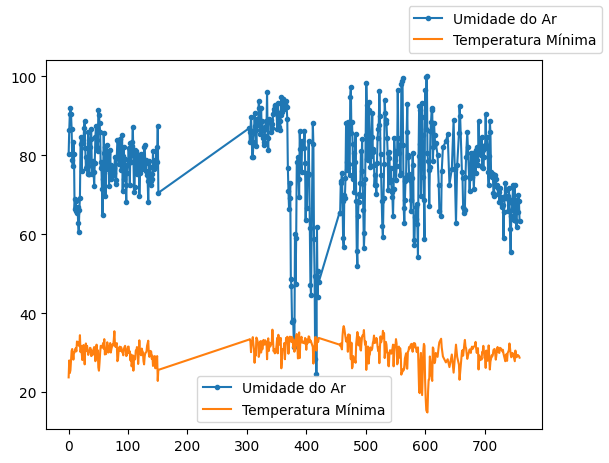

In [10]:
x = df.index # Usa o index como x
y = df['Umidade Relativa do Ar'] # Usa a coluna Umidade Relativa do ar
fig, ax = plt.subplots() # Declara fig, ax

ax.plot(x,y, # Faz um gráfico de linha com x e y
        marker='.', # Usa . como marcador
        label='Umidade do Ar') # Usa a legenda "Umidade do Ar" para estes dados


ax.plot(x, y1, label = 'Temperatura Mínima') # Faz um segundo gráfico

fig.legend() # Gera legendas no topo do gráfico
ax.legend() # Gera legendas no gráfico em si
plt.show() # Mostra a figura

Então, podemos adicionar modificações, como títulos, legenda, e afins, que são feitos através de métodos simples:



```
ax.set_title("Título") # Define o título
ax.set_xlabel("Eixo X") # Define a legenda do eixo X
ax.set_ylabel("Eixo Y") # Define a legenda do eixo Y
ax.grid() # Desenha linhas auxiliares

```



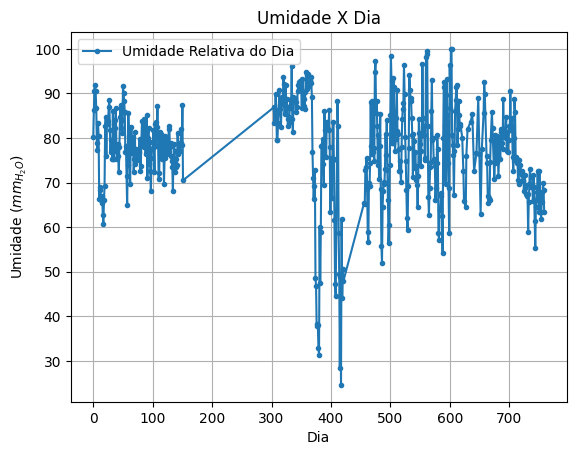

In [12]:
fig, ax = plt.subplots()
ax.plot(x,y, marker='.', label='Umidade Relativa do Dia')
ax.set_title(r"Umidade X Dia") # Define um título para o gráfico
ax.set_xlabel("Dia") # Define a legenda do eixo X
ax.set_ylabel(r"Umidade ($mm_{H_2O}$)") # Define a legenda do eixo Y
ax.legend() # Gera legenda no gráfico
ax.grid() # Gera linhas auxiliars no gráfico
plt.show() # Mostra a figura

Como demonstrado, também é possível a inclusão da formatação **LaTeX**, ao incluir a equação entre `$...$` . Também se coloca um "r" antes da string:


```
r"Aqui vai uma equação: $\frac{1230}{10} = 123$"
```





## Gráficos Múltiplos
O método subplots também permite incluir diversos gráficos em uma única imagem. Ao incluir o número de linhas e de colunas como argumentos em `plt.subplots(n_linhas, n_colunas)`

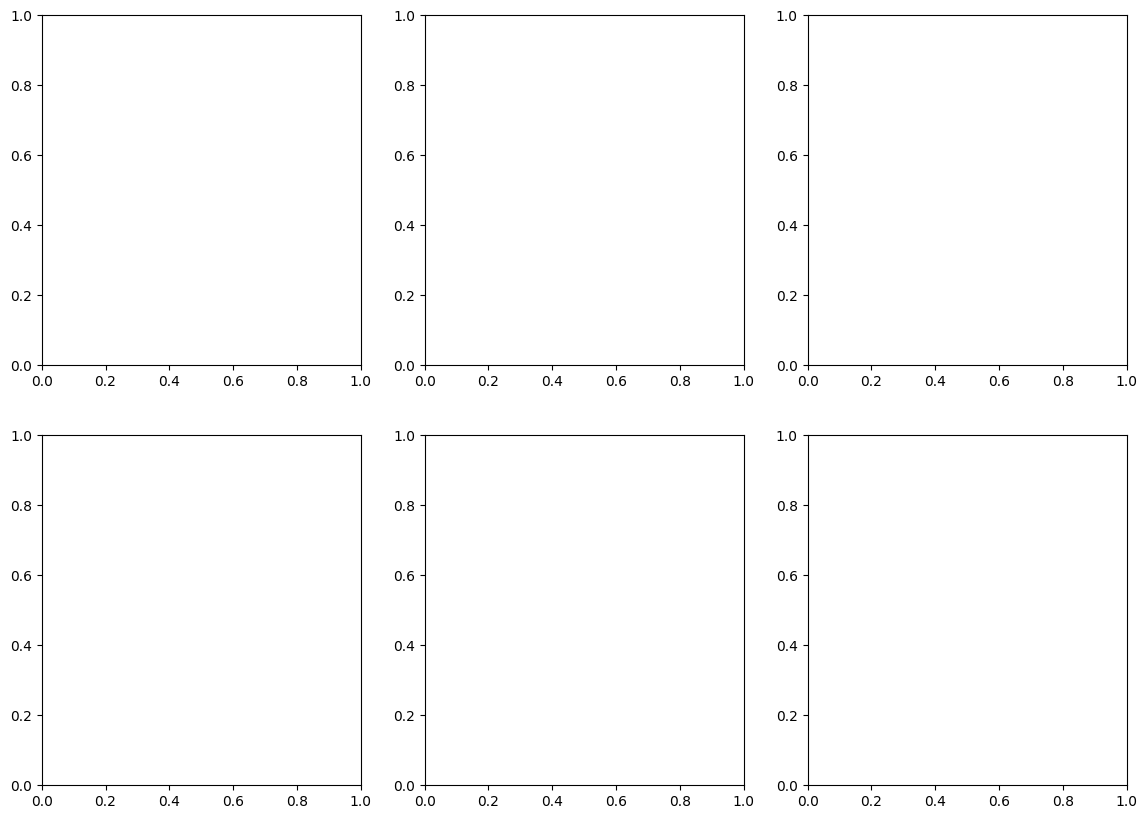

In [14]:
n_rows = 2 # Número de linhas
n_cols = 3 # Número de colunas
fig, axes = plt.subplots(n_rows, n_cols, # Gráfico com 2 linhas e 3 colunas
                         figsize=(14,10)) # Com tamanho de 14 por 10.
plt.show() # Mostra a figura

Como visto, o `axes` retorna uma array, de `n_rows` linhas e `n_cols` colunas. O tamanho da imagem vai ser dito por `figsize=(largura, altura)`, em polegadas.

É possível trabalhar com ela desta forma, e colocar um gráfico na desejada posição por:


```
axes[linha, coluna].plot(x, y)
```



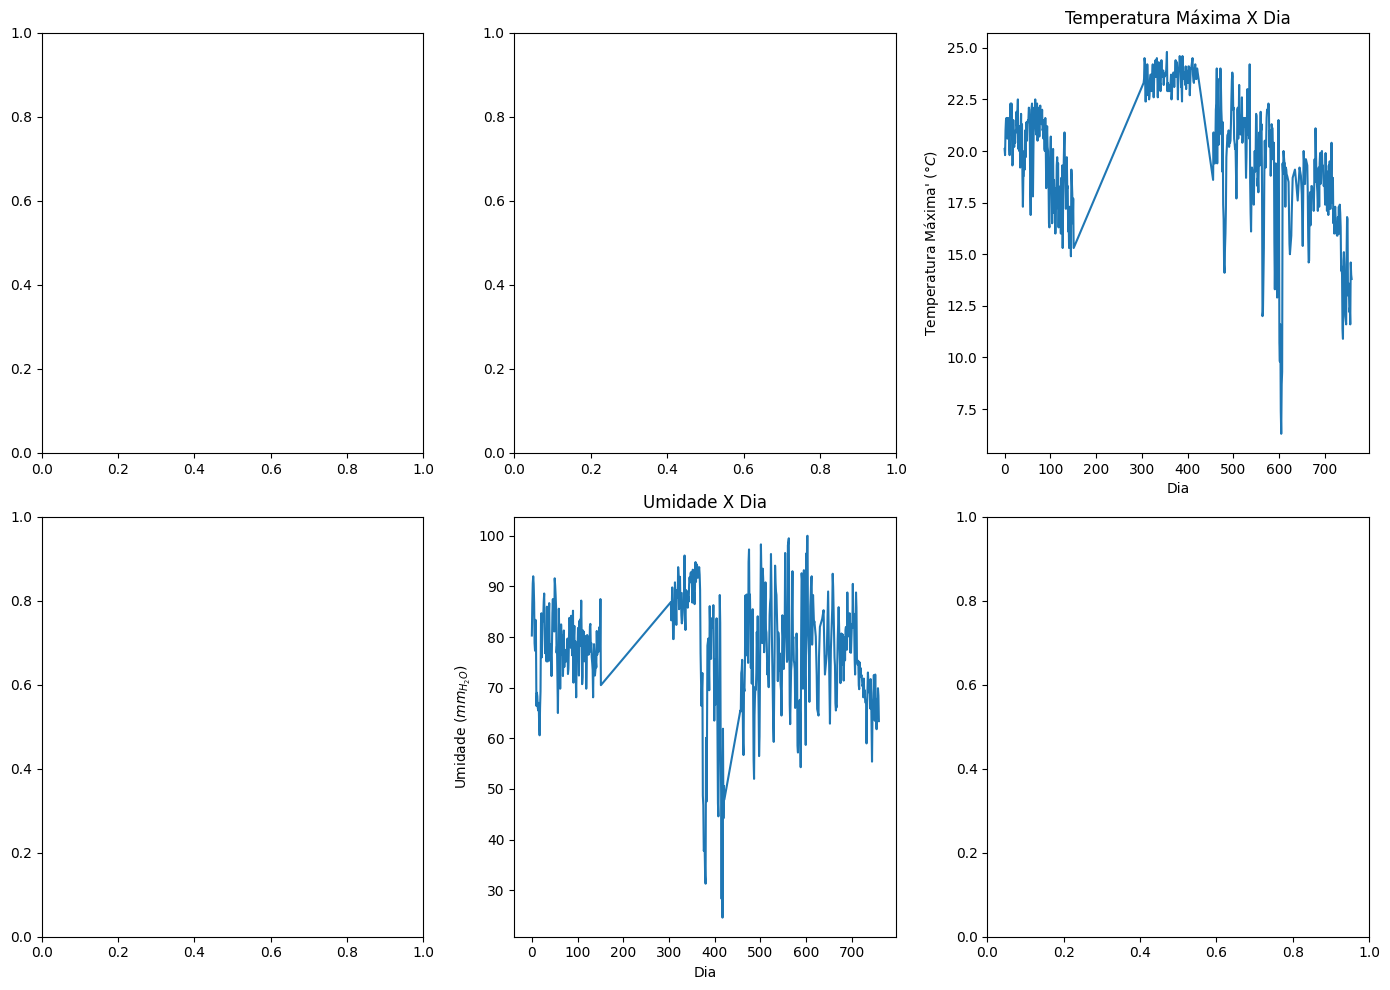

In [15]:
fig, axes = plt.subplots(n_rows,n_cols, figsize=(14,10))

# Define x, y e y1
x = df.index
y = df['Umidade Relativa do Ar']
y1 = df['Temperatura Mínima']

# Vamos trabalhar com o gráfico na segunda linha, segunda coluna:
axes[1,1].plot(x,y)

# As funções normal de ax ainda aplicam:
axes[1,1].set_title(r"Umidade X Dia")
axes[1,1].set_xlabel("Dia") # Define a legenda do eixo X
axes[1,1].set_ylabel(r"Umidade ($mm_{H_2O}$)") # Define a legenda do eixo Y

# Vamos fazer um gráfico para a primeira linha, terceira coluna:
axes[0,2].plot(x,y1)

axes[0,2].set_title(r"Temperatura Máxima X Dia")
axes[0,2].set_xlabel("Dia") # Define a legenda do eixo X
axes[0,2].set_ylabel(r"Temperatura Máxima' ($°C$)") # Define a legenda do eixo Y


fig.tight_layout() # Para prevenir sobreposição entre gráficos


plt.show() # Para mostrar o gráfico

Em gráficos grande, o método `fig.tight_layout()` é adicionado para que não ocorra sobreposição de texto.

Também é possível fazer o plot através do método `.flatten()`, que transforma a lista `m x n` em uma lista unidimensional:

```
axes = axes.flatten()
axes[1].flatten()
```


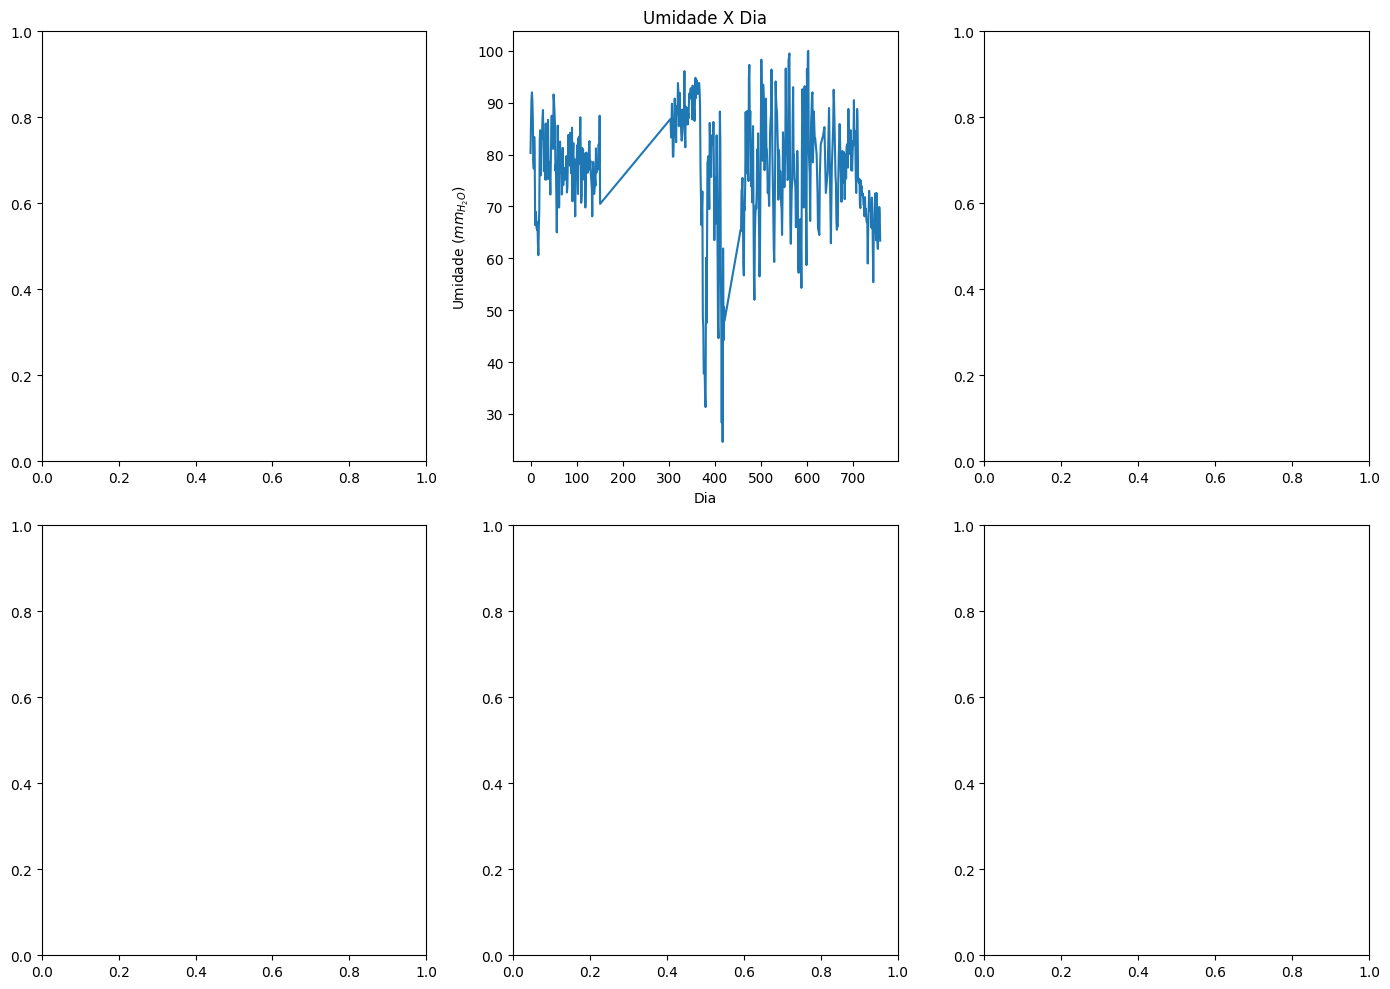

In [16]:
fig, axes = plt.subplots(n_rows,n_cols, figsize=(14,10))

# Transforma axes em uma array unidimensional
axes = axes.flatten()

# Fazer o gráfico no 2° elemento:
axes[1].plot(x,y)


# As funções normal de ax ainda aplicam:
axes[1].set_title(r"Umidade X Dia")
axes[1].set_xlabel("Dia") # Define a legenda do eixo X
axes[1].set_ylabel(r"Umidade ($mm_{H_2O}$)") # Define a legenda do eixo Y

fig.tight_layout() # Para prevenir sobreposição


plt.show() # Para mostrar o gráfico

## Gráficos diretamente da DataFrame

O próprio objeto `DataFrame` possui um método de fazer o gráfico, também chamado de `.plot()`:



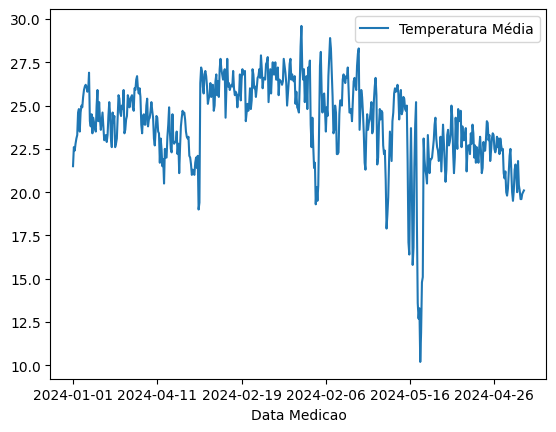

In [17]:
ax = df.plot(x='Data Medicao', # Usa a coluna "Data Medicao" como x
        y='Temperatura Média') # Usa a coluna "Temperatura Média" como y

plt.show() # Mostra o gráfico

Caso seja necessário modificar o gráfico, pode-se atribuir o `df.plot()` para uma variável. Então, modifica-se através dos mesmos métodos.

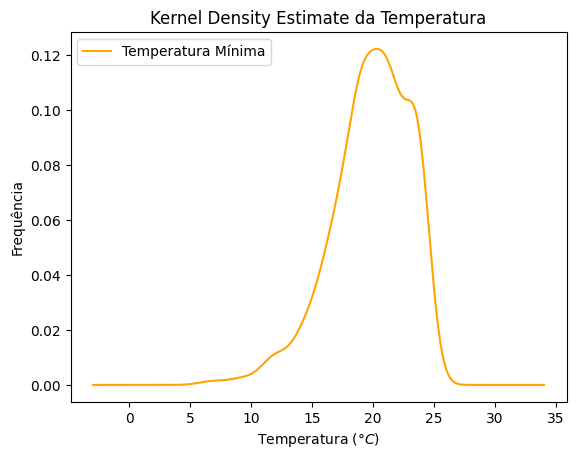

In [18]:
ax = df.plot(y='Temperatura Mínima',
             kind='kde', # Usa um gráfico KDE
             color='orange')
ax.set_title(r"Kernel Density Estimate da Temperatura")
ax.set_ylabel("Frequência") # Define a legenda do eixo y
ax.set_xlabel(r"Temperatura ($°C$)") # Define a legenda do eixo x
plt.show()

# Seaborn
**Seaborn** é uma biblioteca Python para visualização de dados que se baseia no `matplotlib.pyplot` (`plt`) e oferece gráficos mais elegantes e com configurações padrão aprimoradas.

In [19]:
import seaborn as sns

As funções do **Seaborn** também funcionam por métodos, que normalmente são chamados já com a `DataFrame` declarada:


```
df = pd.read_csv(...)

sns.scatterplot(x="Coluna X", y="Coluna Y", data=df)

sns.set(title='Título', xlabel= "Eixo X", ylabel= "Eixo Y")
```





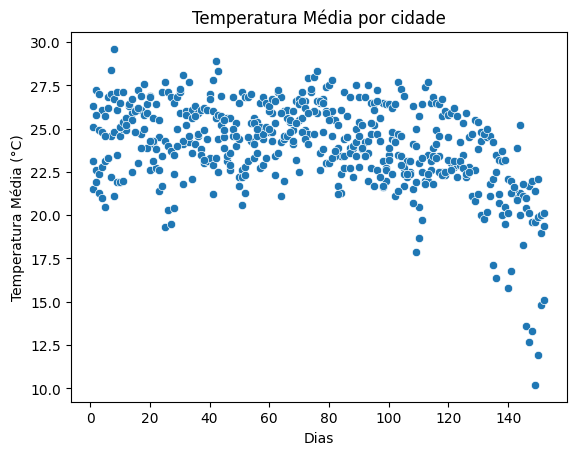

In [21]:
ax = sns.scatterplot(x='Dia', y="Temperatura Média",
                     data=df) # Usa df como fonte dos dados
ax.set(title='Temperatura Média por cidade', # Título do gráfico
       xlabel='Dias', # Legenda do eixo x
       ylabel='Temperatura Média (°C)') # Legenda do eixo y

plt.show() # Mostra o gráfico

Assim como `pyplot`, há vários argumentos possíveis para estes métodos, o de maior interesse é o `hue`:



```
sns.scatterplot(x="Coluna X", y="Coluna Y", data=df, hue='Coluna de Cor')
```



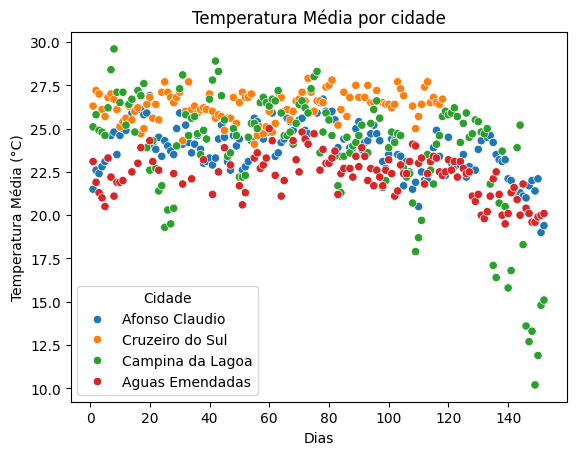

In [23]:
ax = sns.scatterplot(x='Dia', y="Temperatura Média",
                     data=df, # Usa df como fonte de dados
                     hue='Cidade') # Usará valores de Coluna como cores
ax.set(title='Temperatura Média por cidade', xlabel='Dias', ylabel='Temperatura Média (°C)')

plt.show()

## Modificando, assim como pyplot
Como o *seaborn* é construido em cima de `pyplot`, também é possível usar da mesma arquitetura para fazer modificar os gráficos:

Para isso, introduzimos o argumento `ax=...` ao declarar um gráfico por `sns`:

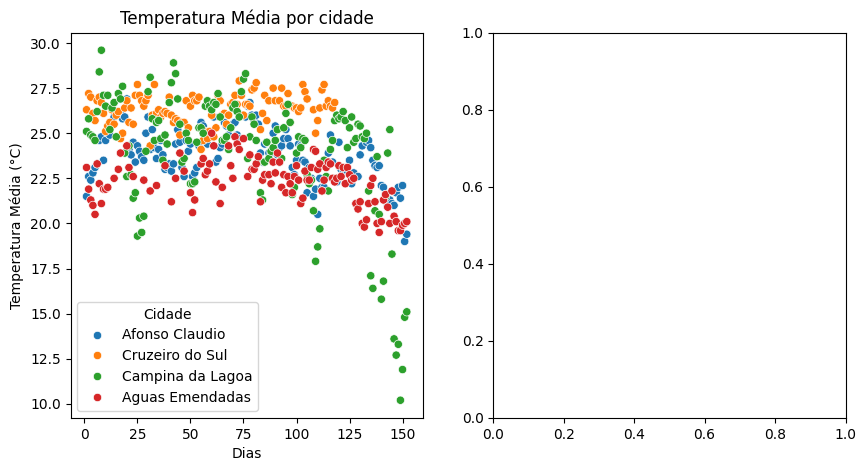

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))
sns.scatterplot(x='Dia', y="Temperatura Média", data=df, hue='Cidade', ax=axes[0])
axes[0].set_title('Temperatura Média por cidade') # Define o título para o primeiro gráfico
axes[0].set_xlabel('Dias') # Define a legenda do eixo x para o primeiro gráfico
axes[0].set_ylabel('Temperatura Média (°C)') # Define a legenda do eixo x para o primeiro gráfico
plt.show() 

## Plots de correlação
Uma das informações que mais nos interessa é a correlação entre as variáveis, que o seaborn permite visualizar por mapas de calor:


O método de gerar um destes gráficos é simples:


```
correl = df.corr() # Atribui as correlações à variável
sns.heatmap(correl) # Faz um gráfico com correl

```


In [26]:
correl = df.corr()

ValueError: could not convert string to float: '2024-01-01'

**Como o erro demonstra, é necessário que haja apenas dados numéricos na DataFrame. Isso, também, pode ser feito por um única função:**


```
df.select_dtypes(include=['float64'])
```



In [27]:
df_apenas_numeros = df.select_dtypes(include=['float64', 'int']) # Seleciona apenas floats
df_apenas_numeros.head() # Mostra as 5 primeiras linhas de df_apenas_numeros

,Precipitação Total,Pressão Atmosférica Média,Temperatura Máxima,Temperatura Média,Temperatura Mínima,Umidade Relativa do Ar,Velocidade do Vento,Dia
0,0.0,956.0,23.7,21.5,20.1,80.3,2.7,1
1,2.4,954.7,28.0,22.6,19.8,86.4,1.1,2
2,39.4,954.8,24.8,22.4,21.0,90.6,1.5,3
3,9.4,953.1,25.5,22.8,21.5,92.0,1.2,4
4,21.0,951.6,28.0,23.1,21.6,90.5,1.2,5


Agora, sim, é possível fazer o gráfico. `annot=True` mostra os valores dentro dos quadrados:

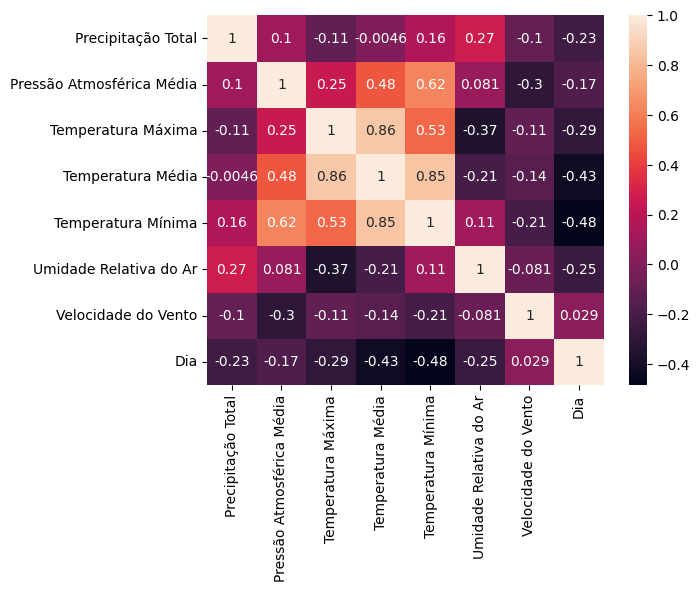

In [31]:
correl = df_apenas_numeros.corr() # Gera uma matriz de correlação entre as variáveis
sns.heatmap(correl, annot=True) # Usa um heatmap para mostrar a matriz
plt.show()

### Pair plots
Outro plot que demonstra a correlação é o pairplot, que é particularmente importante para determinar a utilidade de modelos de previsão.

É importatnte declarar que pairplot é uma função de nível figure.

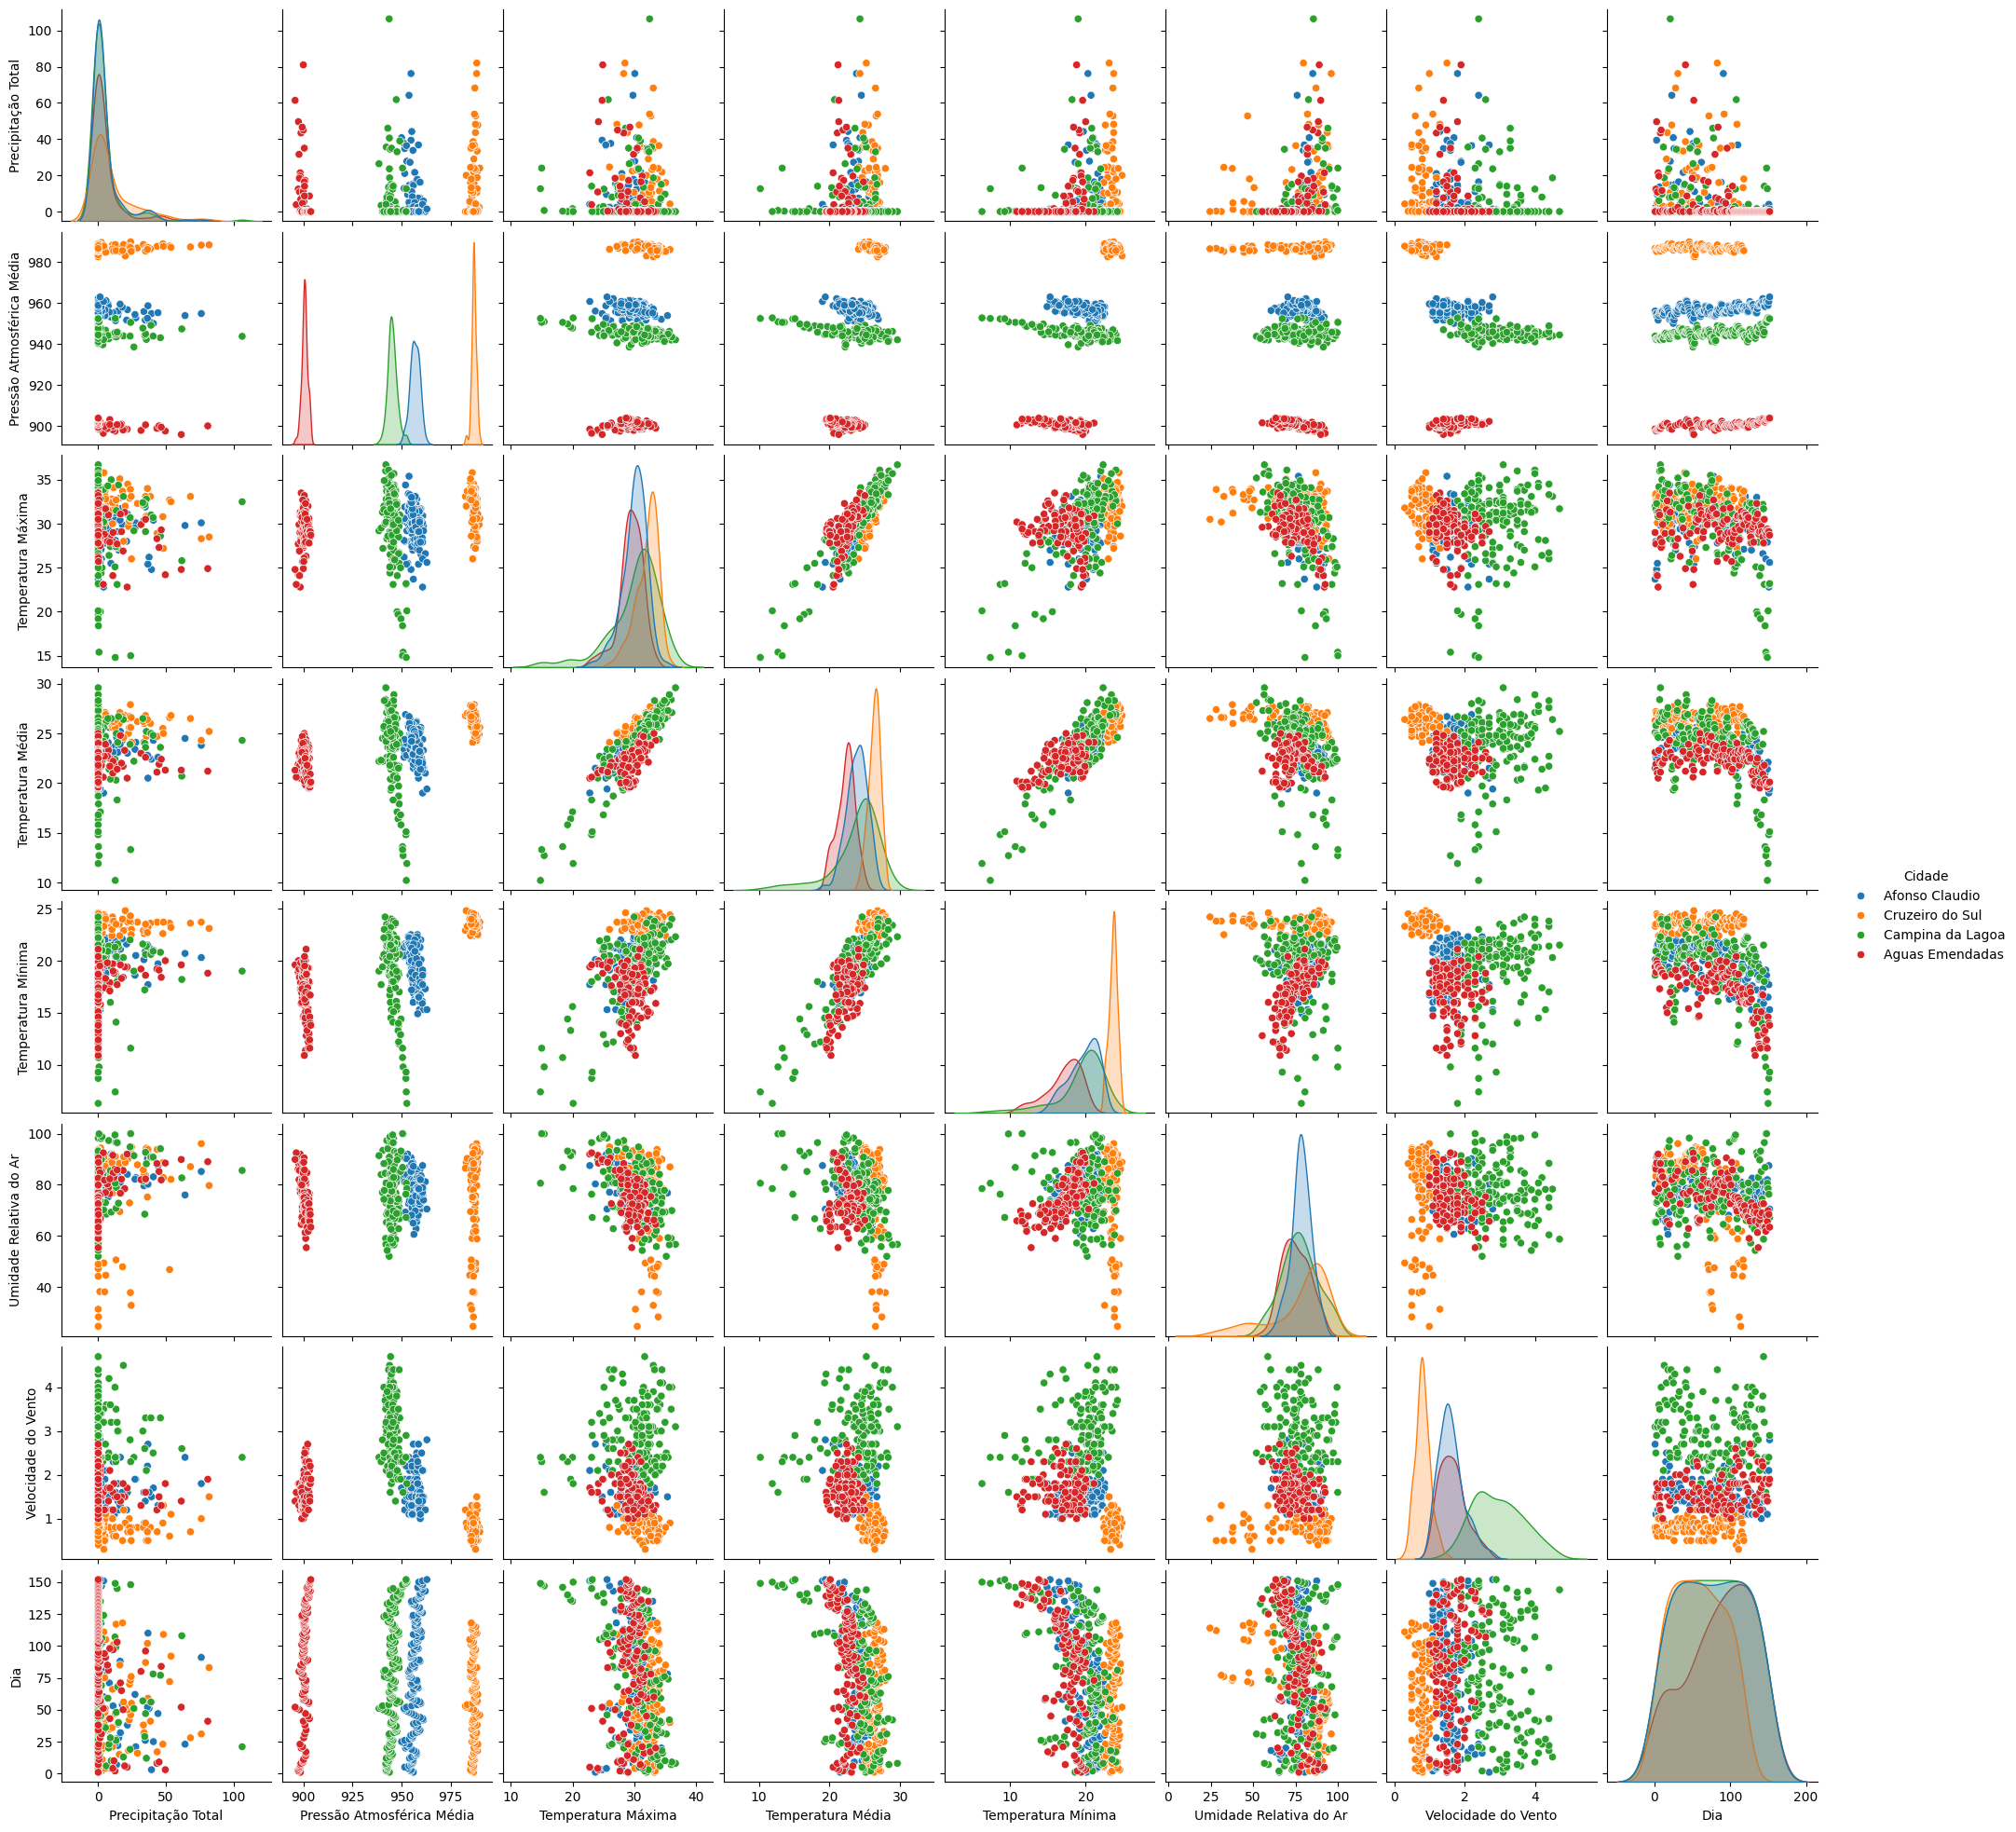

In [33]:
sns.pairplot(data=df, # Usa df como fonte de dados
             hue="Cidade") # Usa a coluna "Cidade" como para as cores
plt.show()

Há alguns [argumentos](https://seaborn.pydata.org/generated/seaborn.pairplot.html) de interesse, como as dadas por `kind`, `markers` e por `corner`.

Veja as diferenças entre cada uma delas:

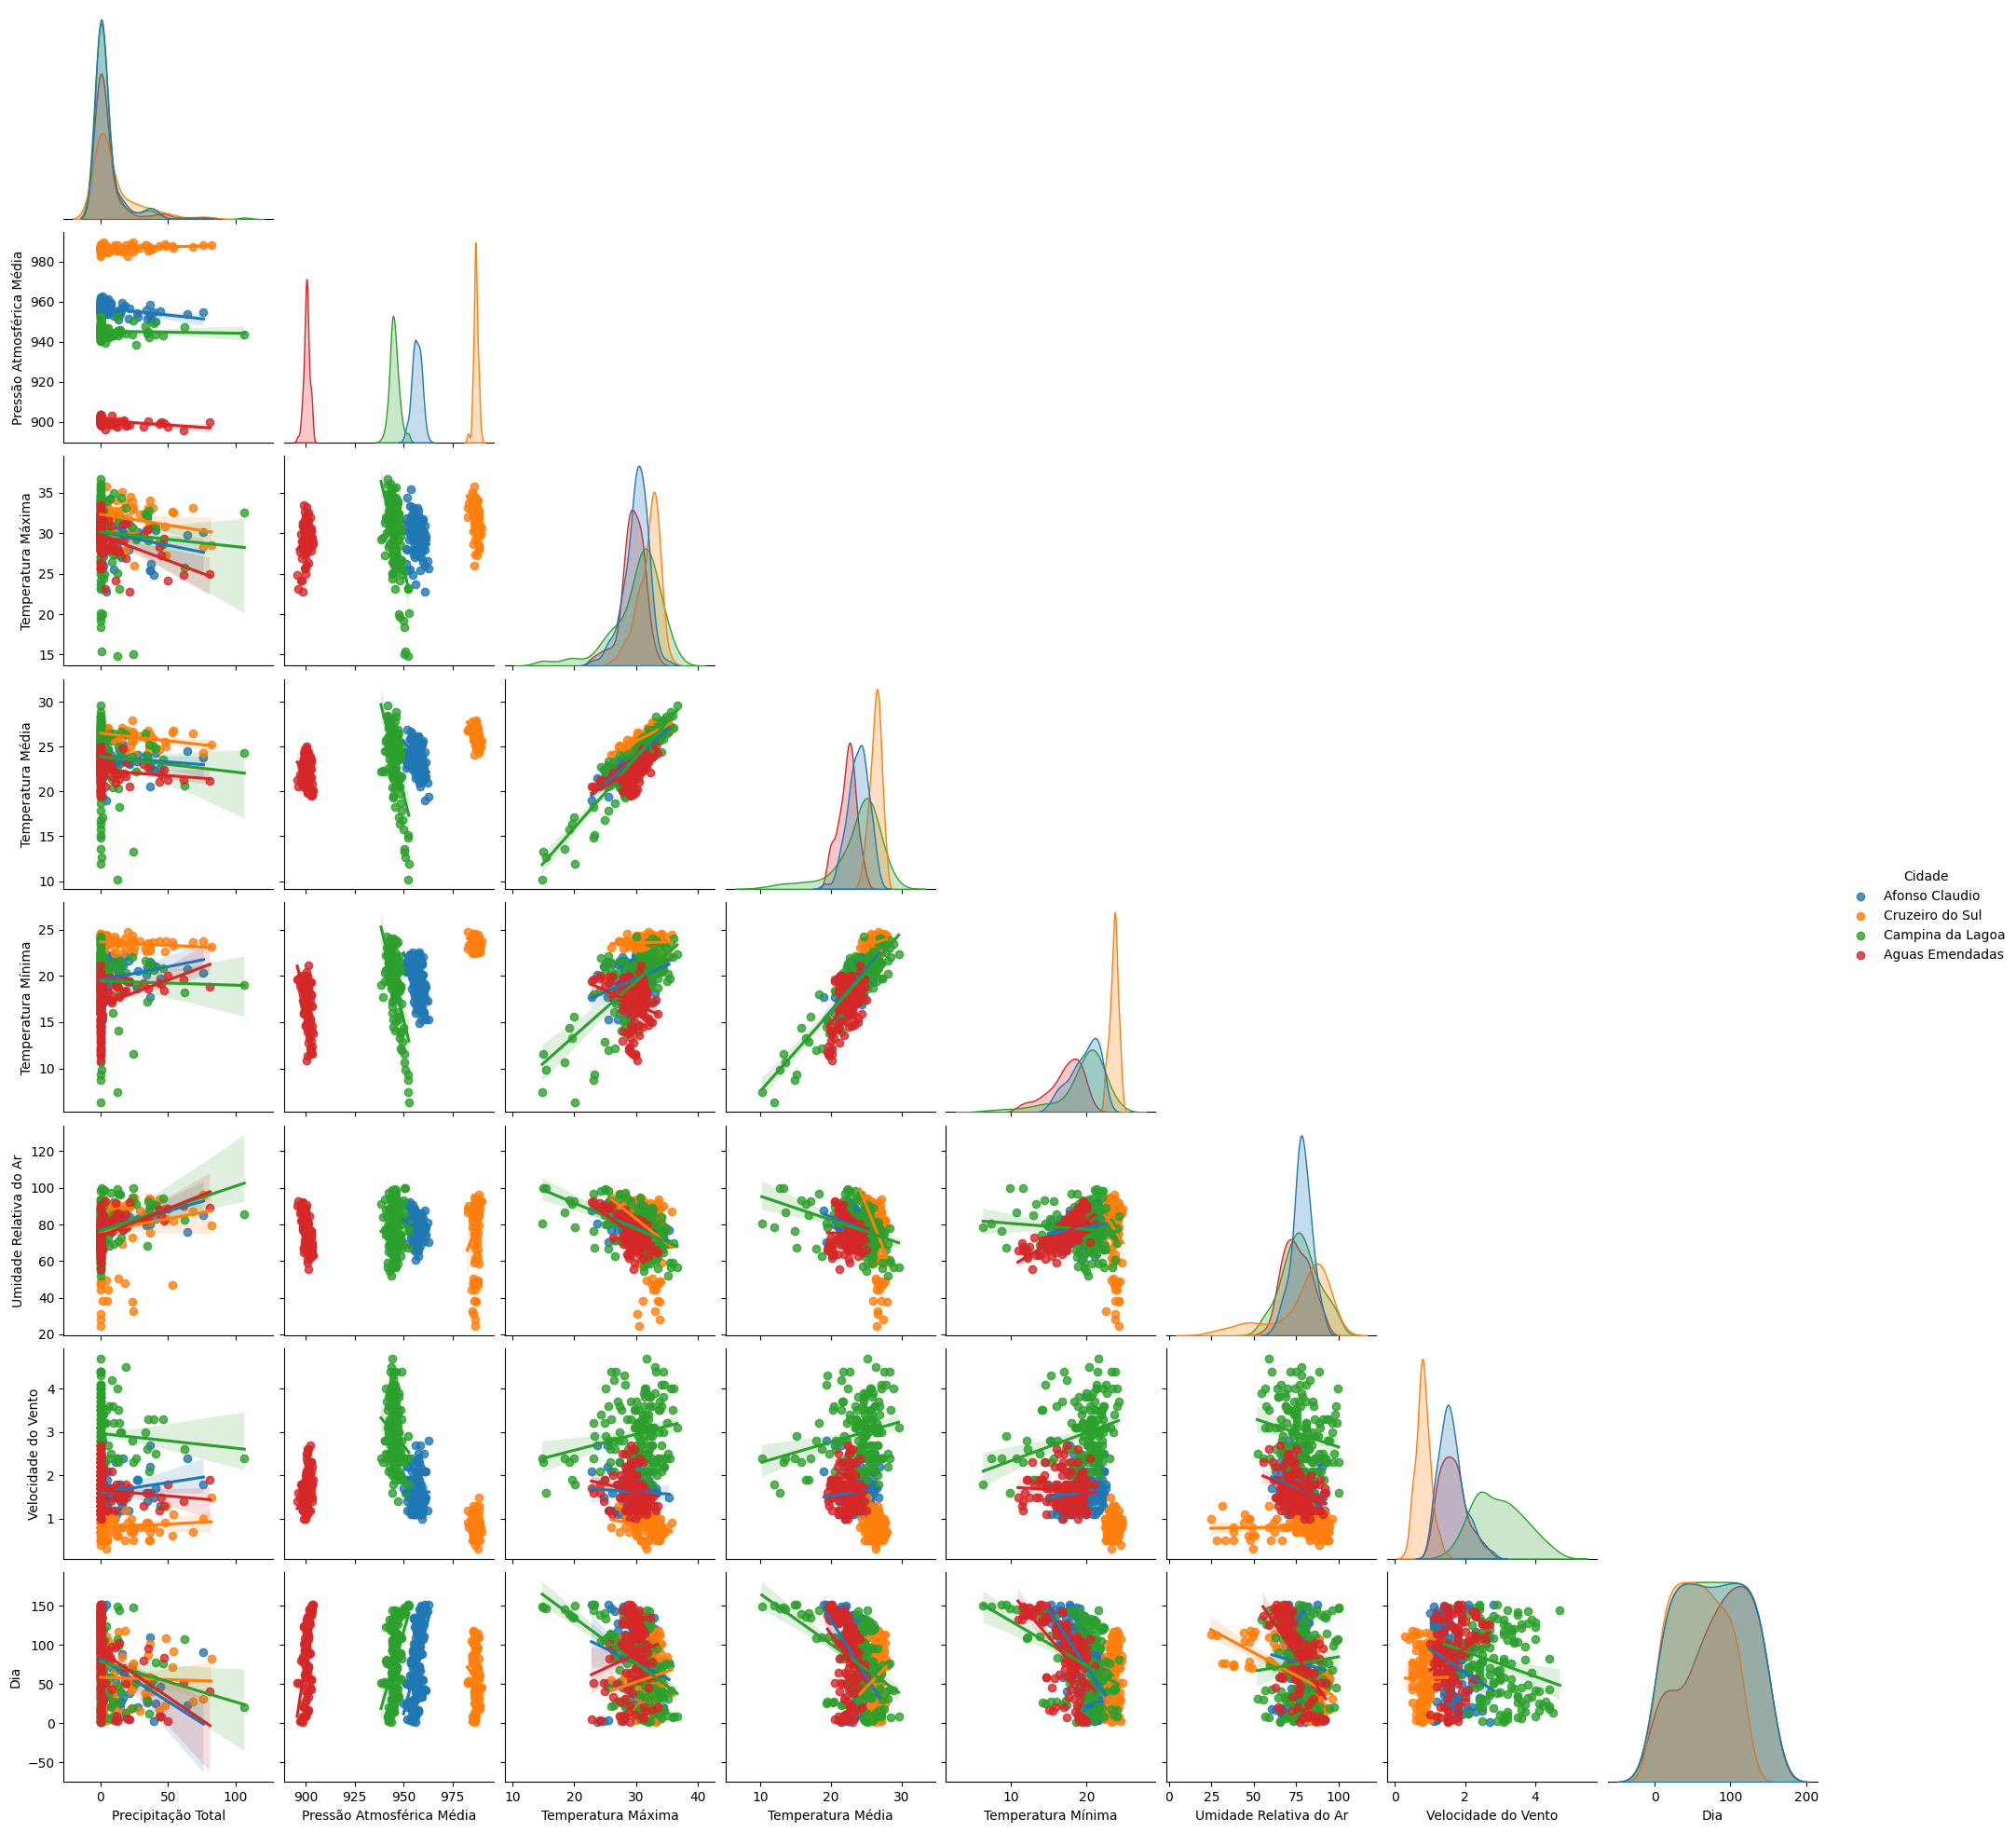

In [ ]:
sns.pairplot(data=df, hue="Cidade",
             kind="reg", # Usa o tipo de gráfico "reg"
             corner=True) # Desenha apenas a parte inferior do gráfico

## Outros tipos de gráficos
Assim como `pyplot`, *seaborn* possui uma documentação extensiva, assim como uma [galeria de exemplo](https://seaborn.pydata.org/examples/index.html)

# Exercício de presença
Acesse a página do [Seaborn](https://seaborn.pydata.org/examples/index.html) e estude mais 3 modelos de gráficos para visualização de dados.


## Exemplo 1

## Exemplo 2

## Exemplo 3